# e4 — Supervised ML for Economic Complexity

Predicts Economic Complexity Index from resource exposure, macro controls,
and institutions. Pooled across M MICE imputations.

Models:
- **Lasso** (CV-tuned regularization for feature selection)
- **Ridge** (CV-tuned regularization, linear baseline)
- **Random Forest** (non-linear, captures interactions)
- **XGBoost** (gradient boosting, if available)

CV: `PanelTemporalCV` — expanding-window, panel-aware, gap=1 between train/val.

Targets:
- **Level**: Economic Complexity Index
- **Delta**: 1-year change (more demanding test of explanatory power)

Pooling across M imputations:
- Predictions: average across M (per row).
- Feature importance: average SHAP values across M.
- R²/RMSE: report mean and between-imputation SD.

Features:
- Trade-side resource shares (`wide_resource_share`, `hydrocarbon_share`, etc.)
- Per-HS-chapter shares
- COVID interactions
- Macro controls (HCI, GFCF, GDP per capita, governance, etc.)
- Rolling 5-year inflation and interest rates


## 1. Setup

In [50]:
import sys, time, warnings, os
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

sys.path.insert(0, '.')
import _config as cfg
from _mice_pool import iter_imputations, n_imputations

from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

try:
    import xgboost as xgb
    HAS_XGB = True
    print('XGBoost available')
except ImportError:
    HAS_XGB = False
    print('XGBoost not available (pip install xgboost --break-system-packages)')

try:
    import shap
    HAS_SHAP = True
    print('SHAP available')
except ImportError:
    HAS_SHAP = False
    print('SHAP not available (pip install shap --break-system-packages)')


# ----------------------------------------------------------------
# MODE switch: 'gross' uses *_share columns, 'net' uses *_share_net.
# Override via env var or by editing the line below.
# ----------------------------------------------------------------
MODE = os.environ.get('CLUSTER_MODE', 'net')
assert MODE in ('gross', 'net'), f"Unknown MODE={MODE!r}; must be 'gross' or 'net'"
print(f'MODE = {MODE}')


def resolve_col(name):
    """Map a gross share column name to its net counterpart when MODE='net'."""
    if MODE == 'gross':
        return name
    return name + '_net'


def _suffix(name):
    """Append _net before the file extension when MODE='net'."""
    if MODE == 'gross':
        return name
    p = Path(name)
    return f'{p.stem}_net{p.suffix}'


EXT  = Path('.').resolve()
INTER = EXT / 'intermediary'
# Route Graphics through MODE subfolder so gross/net coexist
GRAPHICS = EXT / 'Graphics' / 'NB4' / MODE
GRAPHICS.mkdir(parents=True, exist_ok=True)

print(f'Working dir: {EXT}')
print(f'Output dir:  {GRAPHICS}')
print(f'M imputations available: {n_imputations()}')


XGBoost available
SHAP available
MODE = net
Working dir: /Users/leoss/Desktop/GitHub/leoss14.github.io/projects/capstone/New code/extension_2024
Output dir:  /Users/leoss/Desktop/GitHub/leoss14.github.io/projects/capstone/New code/extension_2024/Graphics/NB4/net
M imputations available: 5


## 2. Feature engineering (applied to each imputation)

In [51]:
# COVID sub-codes used for interactions
COVID_INTERACTION_CODES = ['coal', 'crude_oil', 'refined_oil', 'gas', 'ores', 'base_metals']


def engineer_features(panel):
    """Apply feature engineering identical to each of M panels.

    Under MODE='net' this also constructs post2019_x_*_share_net interaction
    columns (matching the e5 logic) since they aren't pre-computed in the
    parquet for net.
    """
    df = panel.copy()
    df = df.sort_values(['Country Code', 'Year'])

    # Rolling 5-year macro controls
    if 'Inflation, consumer prices (annual %)' in df.columns:
        df['Inflation_roll5'] = (
            df.groupby('Country Code')['Inflation, consumer prices (annual %)']
              .transform(lambda x: x.rolling(5, min_periods=3).mean())
        )
    if 'Real interest rate (%)' in df.columns:
        df['RealRate_roll5'] = (
            df.groupby('Country Code')['Real interest rate (%)']
              .transform(lambda x: x.rolling(5, min_periods=3).mean())
        )

    # Resource concentration via HHI on trade chapter shares.
    # Under MODE='net' use the _net share columns; clip negatives at 0 since
    # HHI on a basket with negative components is ill-defined.
    hs_share_cols = [c for c in df.columns
                     if c.startswith('hs')
                     and c.endswith('_share_net' if MODE == 'net' else '_share')
                     and (c.endswith('_share_net') == (MODE == 'net'))]
    # Defensive: in net mode we want columns ending in _share_net, not _share
    if MODE == 'net':
        hs_share_cols = [c for c in df.columns if c.startswith('hs') and c.endswith('_share_net')]
    else:
        hs_share_cols = [c for c in df.columns
                         if c.startswith('hs') and c.endswith('_share')
                         and not c.endswith('_share_net')]

    if hs_share_cols:
        clipped = df[hs_share_cols].clip(lower=0)
        share_sum = clipped.sum(axis=1).replace(0, np.nan)
        normalised = clipped.div(share_sum, axis=0)
        df['Resource_HHI_trade'] = (normalised ** 2).sum(axis=1)

    # Log transforms (mode-invariant)
    for raw, log in [
        ('Human capital index', 'log_HCI'),
        ('Gross fixed capital formation, all, Constant prices, Percent of GDP', 'log_GFCF'),
        ('GDP per capita (constant prices, PPP)', 'log_GDPpc'),
        ('Population', 'log_Pop'),
    ]:
        if raw in df.columns:
            df[log] = np.log(df[raw].clip(lower=0) + 1)

    # Lagged ECI
    df['L1_ECI'] = df.groupby('Country Code')['Economic Complexity Index'].shift(1)
    df['ECI_delta'] = df['Economic Complexity Index'] - df['L1_ECI']

    # Build post2019_x_*_share_net interactions when MODE='net'
    # (Gross variants are pre-computed in the parquet by e2.)
    if MODE == 'net':
        for code in COVID_INTERACTION_CODES:
            sub_col = f'{code}_share_net'
            int_col = f'post2019_x_{code}_share'
            if sub_col in df.columns and 'post_2019' in df.columns:
                df[int_col] = df['post_2019'] * df[sub_col]

    return df


# Feature list. Resource-share entries route through resolve_col.
# COVID interaction names stay literal (their source columns pick up the
# _net suffix in engineer_features above).
FEATURE_COLS = [
    # Trade-side resource exposure (headline)
    resolve_col('wide_resource_share'),
    resolve_col('hydrocarbon_share'),
    resolve_col('ores_share'),
    resolve_col('base_metals_share'),
    resolve_col('precious_share'),
    'Resource_HHI_trade',
    # COVID interactions
    'post2019_x_coal_share',
    'post2019_x_crude_oil_share',
    'post2019_x_refined_oil_share',
    'post2019_x_gas_share',
    'post2019_x_ores_share',
    'post2019_x_base_metals_share',
    # Macro
    'log_GDPpc',
    'log_Pop',
    'log_HCI',
    'log_GFCF',
    'Trade (% of GDP)',
    'Domestic credit to private sector (% of GDP)',
    # Sectoral
    'Agriculture',
    'Industry',
    'Manufacturing',
    'Services',
    'Urban population (% of total population)',
    # Governance
    'Political stability — estimate',
    'Rule of law index',
    'Political corruption index',
    # Monetary
    'Inflation_roll5',
    'RealRate_roll5',
    # Lagged ECI (autoregressive component)
    'L1_ECI',
]

# Verify on first imputation
imp0 = engineer_features(next(iter_imputations())[1])
present = [c for c in FEATURE_COLS if c in imp0.columns]
missing = [c for c in FEATURE_COLS if c not in imp0.columns]
print(f'Features available ({MODE}): {len(present)} / {len(FEATURE_COLS)}')
if missing:
    print(f'  MISSING: {missing}')

# FEATURES is the canonical feature list used by downstream cells (train_models
# default, SHAP labelling, structural-spec construction). Under MODE='net' this
# carries the *_net suffix on the resource share entries; under MODE='gross' it
# uses the plain *_share names.
FEATURES = present


Features available (net): 29 / 29


## 3. Panel-aware temporal cross-validation

In [52]:
class PanelTemporalCV:
    """Expanding-window CV for panels: train on years <= cutoff, validate on years > cutoff + gap."""
    def __init__(self, years, n_splits=5, gap=1, min_train_years=8):
        self.years = np.asarray(years)
        self.n_splits = n_splits
        self.gap = gap
        self.min_train_years = min_train_years
        uy = np.sort(np.unique(self.years))
        ec = uy[0] + min_train_years - 1
        lc = uy[-1] - gap - 1
        if ec > lc:
            raise ValueError(f'Year range too narrow')
        self.cutoffs = np.linspace(ec, lc, n_splits).astype(int)

    def split(self, X=None, y=None, groups=None):
        for c in self.cutoffs:
            tr = np.where(self.years <= c)[0]
            va = np.where(self.years > c + self.gap)[0]
            if len(tr) > 0 and len(va) > 0:
                yield tr, va

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


print('CV class defined.')


CV class defined.


## 4. Train models on a single panel

In [53]:
from sklearn.linear_model import Lasso, Ridge

def train_models(df_engineered, feature_list=None, target='Economic Complexity Index'):
    """Train Lasso, Ridge, RF (+XGBoost if available) on a single engineered panel.

    Parameters
    ----------
    df_engineered : DataFrame returned by engineer_features().
    feature_list  : list of column names to use as features. Defaults to the
        module-level FEATURES global (the 'forecast' spec including L1_ECI).
        Pass a custom list for alternative specs (e.g., a structural spec
        with L1_ECI removed to isolate non-autoregressive drivers).
    target        : DV column.

    OOF predictions are produced via a per-fold refit using plain Lasso/Ridge
    with the alpha chosen by the outer LassoCV/RidgeCV. This avoids reusing
    the outer PanelTemporalCV splitter (which is bound to the full panel's
    year vector) inside a subset refit."""
    if feature_list is None:
        feature_list = FEATURES
    sub = df_engineered[feature_list + [target, 'Country Code', 'Year']].dropna()
    if len(sub) == 0:
        return None
    X = sub[feature_list].values
    y = sub[target].values
    years = sub['Year'].values

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    cv = PanelTemporalCV(years, n_splits=5, gap=1, min_train_years=8)

    models = {}

    lasso = LassoCV(cv=cv, max_iter=10000, n_alphas=20)
    lasso.fit(Xs, y)
    models['Lasso'] = lasso

    ridge = RidgeCV(cv=cv, alphas=np.logspace(-3, 3, 25))
    ridge.fit(Xs, y)
    models['Ridge'] = ridge

    rf = RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_leaf=4,
        random_state=42, n_jobs=-1,
    )
    rf.fit(Xs, y)
    models['RandomForest'] = rf

    if HAS_XGB:
        xgbm = xgb.XGBRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            random_state=42, n_jobs=-1, verbosity=0,
        )
        xgbm.fit(Xs, y)
        models['XGBoost'] = xgbm

    refit_factory = {
        'Lasso':        lambda: Lasso(alpha=lasso.alpha_, max_iter=10000),
        'Ridge':        lambda: Ridge(alpha=ridge.alpha_),
        'RandomForest': lambda: RandomForestRegressor(
            n_estimators=200, max_depth=15, min_samples_leaf=4,
            random_state=42, n_jobs=-1,
        ),
    }
    if HAS_XGB:
        refit_factory['XGBoost'] = lambda: xgb.XGBRegressor(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            random_state=42, n_jobs=-1, verbosity=0,
        )

    oof = {name: np.full(len(y), np.nan) for name in models}
    fold_scores = {name: [] for name in models}
    for tr, va in cv.split(Xs, y):
        for name in models:
            mod_clone = refit_factory[name]()
            mod_clone.fit(Xs[tr], y[tr])
            pred = mod_clone.predict(Xs[va])
            oof[name][va] = pred
            fold_scores[name].append(r2_score(y[va], pred))

    return {
        'models': models,
        'scaler': scaler,
        'feature_cols': feature_list,
        'X': Xs, 'y': y,
        'sub_idx': sub.index,
        'sub': sub[['Country Code', 'Year']].reset_index(drop=True),
        'oof': oof,
        'fold_scores': fold_scores,
    }


# Sanity check on one imputation
imp1 = engineer_features(next(iter_imputations())[1])
print(f'Engineered panel: {len(imp1):,} rows, {len(FEATURES)} features')


Engineered panel: 3,582 rows, 29 features


## 5. Train across M imputations

In [54]:
# Train all model on each of M imputations, collect OOF predictions and CV scores
all_results = []
all_oof = {}  # imp_id -> dict
print(f'Training {1 + (1 if HAS_XGB else 0) + 2} models across M imputations...')
t0 = time.time()

for imp_id, panel in iter_imputations():
    t_i = time.time()
    eng = engineer_features(panel)
    res = train_models(eng)
    if res is None:
        print(f'  imp {imp_id}: empty panel after dropna')
        continue

    for name in res['models']:
        scores = res['fold_scores'][name]
        oof = res['oof'][name]
        mask = ~np.isnan(oof)
        all_results.append({
            'imputation': imp_id,
            'model': name,
            'cv_r2_mean': float(np.mean(scores)),
            'cv_r2_std':  float(np.std(scores)),
            'oof_r2':     r2_score(res['y'][mask], oof[mask]) if mask.any() else np.nan,
            'oof_mae':    mean_absolute_error(res['y'][mask], oof[mask]) if mask.any() else np.nan,
            'oof_rmse':   np.sqrt(mean_squared_error(res['y'][mask], oof[mask])) if mask.any() else np.nan,
            'n_train':    int(mask.sum()),
        })
    all_oof[imp_id] = res
    print(f'  imp {imp_id}: trained in {time.time() - t_i:.1f}s')

print(f'\nTotal: {time.time() - t0:.1f}s')
results_df = pd.DataFrame(all_results)
print()
print(results_df.to_string(index=False))


Training 4 models across M imputations...
  imp 0: trained in 13.9s
  imp 1: trained in 11.0s
  imp 2: trained in 12.7s
  imp 3: trained in 13.7s
  imp 4: trained in 12.9s

Total: 64.3s

 imputation        model  cv_r2_mean  cv_r2_std   oof_r2  oof_mae  oof_rmse  n_train
          0        Lasso    0.962781   0.007263 0.957345 0.102349  0.167616     1205
          0        Ridge    0.961090   0.007876 0.956588 0.104089  0.169098     1205
          0 RandomForest    0.953221   0.016396 0.950668 0.110882  0.180258     1205
          0      XGBoost    0.938208   0.025254 0.938006 0.123048  0.202072     1205
          1        Lasso    0.962731   0.007315 0.957279 0.102349  0.167746     1205
          1        Ridge    0.961004   0.007895 0.956522 0.104173  0.169227     1205
          1 RandomForest    0.953184   0.016544 0.950581 0.111119  0.180417     1205
          1      XGBoost    0.937502   0.028818 0.938243 0.122770  0.201685     1205
          2        Lasso    0.962757   0.007288 

## 6. Pool predictions and scores

In [55]:
# Per-model: average OOF predictions across imputations, compute pooled R^2
pooled_results = []
for name in results_df['model'].unique():
    # Stack OOF predictions: (M, N) but each imp has different sub_idx,
    # so we align on (Country Code, Year)
    preds_list = []
    for imp_id, res in all_oof.items():
        pred_df = res['sub'].copy()
        pred_df['pred'] = res['oof'][name]
        # Drop rows where OOF prediction is NaN (early years are never in
        # any validation fold under PanelTemporalCV with min_train_years=8)
        pred_df = pred_df.dropna(subset=['pred'])
        preds_list.append(pred_df)

    stacked = pd.concat(preds_list, ignore_index=True)
    if len(stacked) == 0:
        continue
    pooled_pred = stacked.groupby(['Country Code', 'Year'])['pred'].mean().reset_index()

    # Ground truth: use observed-only ECI from e2 (cleaner than imp0's
    # imputed ECI, since ECI is itself a MICE target and using a single
    # imputation as both truth and feature would understate evaluation error)
    obs = pd.read_csv(INTER / 'Master_v2_observed.csv')
    truth = obs[['Country Code', 'Year', 'Economic Complexity Index']].dropna()
    merged = truth.merge(pooled_pred, on=['Country Code', 'Year'], how='inner')
    if len(merged) == 0:
        continue

    pooled_results.append({
        'model':       name,
        'pooled_r2':   r2_score(merged['Economic Complexity Index'], merged['pred']),
        'pooled_mae':  mean_absolute_error(merged['Economic Complexity Index'], merged['pred']),
        'pooled_rmse': np.sqrt(mean_squared_error(merged['Economic Complexity Index'], merged['pred'])),
        'n_pooled':    len(merged),
    })

pooled_df = pd.DataFrame(pooled_results)
print('Pooled across M imputations (evaluated on observed-only ECI):')
print(pooled_df.to_string(index=False))

# Save full results
out = INTER / _suffix('e4_results.csv')
results_df.to_csv(out, index=False)
print(f'\nSaved per-imputation: {out}')

out_pooled = INTER / _suffix('e4_results_pooled.csv')
pooled_df.to_csv(out_pooled, index=False)
print(f'Saved pooled:          {out_pooled}')


Pooled across M imputations (evaluated on observed-only ECI):
       model  pooled_r2  pooled_mae  pooled_rmse  n_pooled
       Lasso   0.957312    0.102339     0.167682      1205
       Ridge   0.956572    0.104097     0.169129      1205
RandomForest   0.950606    0.110877     0.180371      1205
     XGBoost   0.938194    0.122366     0.201766      1205

Saved per-imputation: /Users/leoss/Desktop/GitHub/leoss14.github.io/projects/capstone/New code/extension_2024/intermediary/e4_results_net.csv
Saved pooled:          /Users/leoss/Desktop/GitHub/leoss14.github.io/projects/capstone/New code/extension_2024/intermediary/e4_results_pooled_net.csv


## 7. Feature importance (SHAP, pooled)

In [56]:
if not HAS_SHAP:
    print('SHAP not available, skipping importance computation.')
else:
    # Compute SHAP for RF on each imputation, average
    print('Computing SHAP values across M imputations...')
    t0 = time.time()
    shap_per_imp = []
    for imp_id, res in all_oof.items():
        rf = res['models']['RandomForest']
        Xs = res['X']
        explainer = shap.TreeExplainer(rf)
        sv = explainer.shap_values(Xs)
        # Mean absolute SHAP per feature
        importances = np.abs(sv).mean(axis=0)
        shap_per_imp.append(importances)
        print(f'  imp {imp_id} done in {time.time() - t0:.1f}s')

    shap_arr = np.array(shap_per_imp)
    shap_mean = shap_arr.mean(axis=0)
    shap_std = shap_arr.std(axis=0)

    shap_df = pd.DataFrame({
        'feature': FEATURES,
        'shap_mean': shap_mean,
        'shap_std':  shap_std,
        'shap_sd_rel': shap_std / (shap_mean + 1e-8),
    }).sort_values('shap_mean', ascending=False)

    print('\nTop-15 features by pooled SHAP importance:')
    print(shap_df.head(15).to_string(index=False))

    out_shap = INTER / _suffix('e4_shap.csv')
    shap_df.to_csv(out_shap, index=False)
    print(f'\nSaved: {out_shap}')


Computing SHAP values across M imputations...
  imp 0 done in 10.1s
  imp 1 done in 20.2s
  imp 2 done in 30.3s
  imp 3 done in 40.6s
  imp 4 done in 51.2s

Top-15 features by pooled SHAP importance:
                                     feature  shap_mean  shap_std  shap_sd_rel
                                      L1_ECI   0.649174  0.000109     0.000167
                                   log_GDPpc   0.005701  0.000109     0.019064
                          precious_share_net   0.003791  0.000102     0.026981
                              ores_share_net   0.003533  0.000037     0.010342
                                 Agriculture   0.003516  0.000100     0.028311
                                    Services   0.003466  0.000045     0.013052
                                    Industry   0.003310  0.000053     0.015991
                               Manufacturing   0.003305  0.000090     0.027151
                                     log_HCI   0.003234  0.000041     0.012820
Domestic c

## 8. Coefficient table (Lasso, Ridge averaged across M)

In [57]:
# For linear models, average coefficients across M imputations
def collect_linear_coefs(model_name):
    coef_rows = []
    for imp_id, res in all_oof.items():
        model = res['models'][model_name]
        if hasattr(model, 'coef_'):
            for feat, coef in zip(res['feature_cols'], model.coef_):
                coef_rows.append({'imp': imp_id, 'feature': feat, 'coef': coef})
    return pd.DataFrame(coef_rows)

for name in ['Lasso', 'Ridge']:
    df_coef = collect_linear_coefs(name)
    if df_coef.empty:
        continue
    pivot = (df_coef.groupby('feature')['coef']
                    .agg(['mean', 'std', 'count'])
                    .sort_values('mean', key=abs, ascending=False))
    pivot['nonzero_rate'] = df_coef.groupby('feature')['coef'].apply(lambda x: (x.abs() > 1e-8).mean())
    print(f'\n{name} (pooled across M):')
    print(pivot.head(15).to_string())



Lasso (pooled across M):
                                                  mean       std  count  nonzero_rate
feature                                                                              
L1_ECI                                        0.737892  0.000211      5           1.0
log_GDPpc                                     0.018796  0.000132      5           1.0
Manufacturing                                 0.015736  0.000424      5           1.0
Domestic credit to private sector (% of GDP)  0.005637  0.000394      5           1.0
ores_share_net                               -0.004669  0.000139      5           1.0
wide_resource_share_net                      -0.004602  0.000073      5           1.0
Rule of law index                             0.003228  0.000082      5           1.0
Services                                      0.002831  0.000413      5           1.0
log_HCI                                       0.000864  0.000028      5           1.0
log_Pop                     

## 9. Visualisations

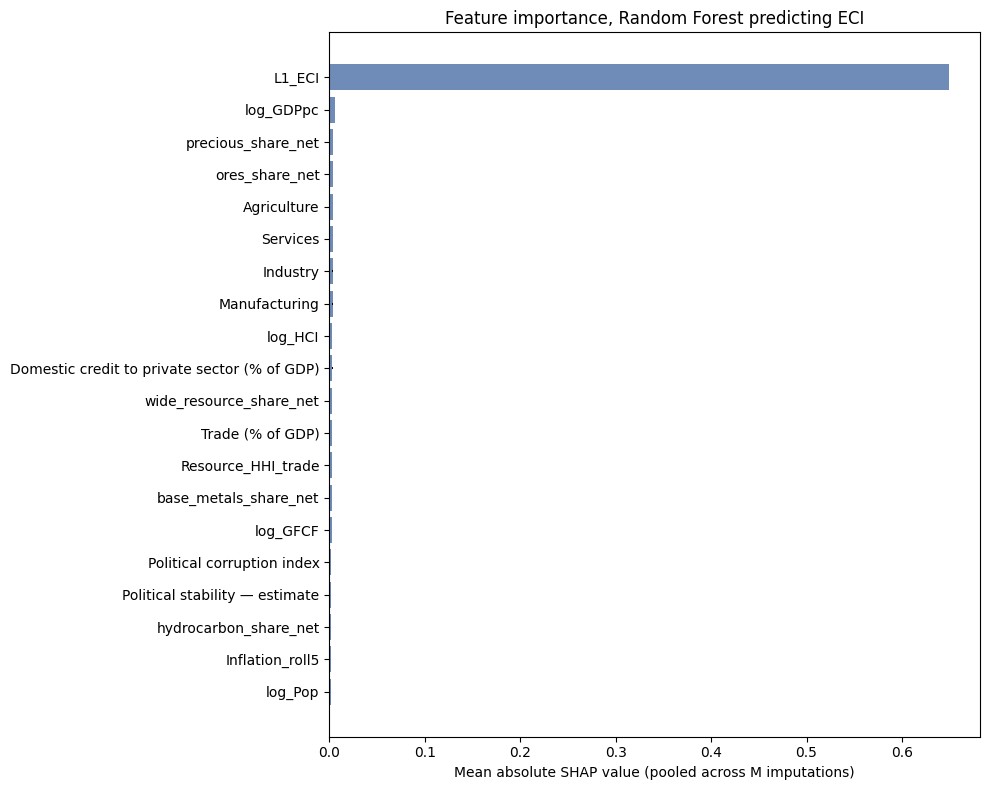

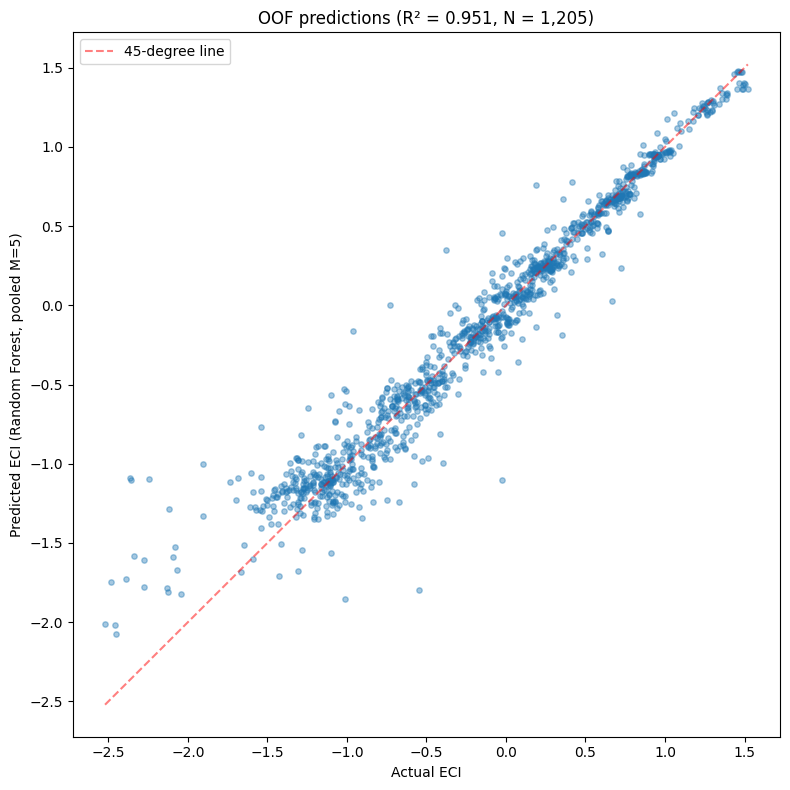

Saved: /Users/leoss/Desktop/GitHub/leoss14.github.io/projects/capstone/New code/extension_2024/intermediary/e4_predictions_net.csv


In [58]:
# Bar chart of feature importance
if HAS_SHAP:
    fig, ax = plt.subplots(figsize=(10, 8))
    top = shap_df.head(20)
    ax.barh(top['feature'], top['shap_mean'], xerr=top['shap_std'],
            color='#4a6fa5', alpha=0.8)
    ax.invert_yaxis()
    ax.set_xlabel('Mean absolute SHAP value (pooled across M imputations)')
    ax.set_title('Feature importance, Random Forest predicting ECI')
    plt.tight_layout()
    plt.savefig(GRAPHICS / _suffix('feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Predicted vs actual ECI (RF, pooled). Drop NaN OOF predictions (early years
# are not in any validation fold under PanelTemporalCV with min_train_years=8).
# Truth comes from observed-only ECI so we evaluate against real data, not
# MICE's imputation of ECI.
obs = pd.read_csv(INTER / 'Master_v2_observed.csv')
truth = obs[['Country Code', 'Year', 'Economic Complexity Index']].dropna()

rf_preds = []
for imp_id, res in all_oof.items():
    sub = res['sub'].copy()
    sub['pred'] = res['oof']['RandomForest']
    sub = sub.dropna(subset=['pred'])
    rf_preds.append(sub)
all_rf_pred = pd.concat(rf_preds, ignore_index=True)
pooled_rf = all_rf_pred.groupby(['Country Code', 'Year'])['pred'].mean().reset_index()
merged = truth.merge(pooled_rf, on=['Country Code', 'Year'], how='inner')

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(merged['Economic Complexity Index'], merged['pred'], alpha=0.4, s=15)
lims = [min(merged['Economic Complexity Index'].min(), merged['pred'].min()),
        max(merged['Economic Complexity Index'].max(), merged['pred'].max())]
ax.plot(lims, lims, 'r--', alpha=0.5, label='45-degree line')
ax.set_xlabel('Actual ECI')
ax.set_ylabel('Predicted ECI (Random Forest, pooled M=5)')
r2 = r2_score(merged['Economic Complexity Index'], merged['pred'])
ax.set_title(f'OOF predictions (R\u00b2 = {r2:.3f}, N = {len(merged):,})')
ax.legend()
plt.tight_layout()
plt.savefig(GRAPHICS / _suffix('predictions_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save predictions
out_preds = INTER / _suffix('e4_predictions.csv')
pooled_rf.to_csv(out_preds, index=False)
print(f'Saved: {out_preds}')


## 10. Summary

In [59]:
print('=' * 70)
print('e4 — ML summary')
print('=' * 70)
print(f'Imputations:  {results_df["imputation"].nunique()}')
print(f'Models:       {", ".join(results_df["model"].unique())}')
print()
print('Pooled performance (predictions averaged across M):')
print(pooled_df.to_string(index=False))
print()
print('Files:')
print(f'  intermediary/e4_results.csv     (per-imputation CV scores)')
print(f'  intermediary/e4_predictions.csv (pooled per-country-year)')
print(f'  intermediary/e4_shap.csv        (pooled feature importance)')
print(f'  Graphics/NB4/feature_importance.png')
print(f'  Graphics/NB4/predictions_scatter.png')
print()
print('Next: e6 (forecasting), e7+ (robustness/visualization)')


e4 — ML summary
Imputations:  5
Models:       Lasso, Ridge, RandomForest, XGBoost

Pooled performance (predictions averaged across M):
       model  pooled_r2  pooled_mae  pooled_rmse  n_pooled
       Lasso   0.957312    0.102339     0.167682      1205
       Ridge   0.956572    0.104097     0.169129      1205
RandomForest   0.950606    0.110877     0.180371      1205
     XGBoost   0.938194    0.122366     0.201766      1205

Files:
  intermediary/e4_results.csv     (per-imputation CV scores)
  intermediary/e4_predictions.csv (pooled per-country-year)
  intermediary/e4_shap.csv        (pooled feature importance)
  Graphics/NB4/feature_importance.png
  Graphics/NB4/predictions_scatter.png

Next: e6 (forecasting), e7+ (robustness/visualization)


STRUCTURAL SPEC (L1_ECI removed)
Structural feature set: 27 features (was 29)
  imp 0: trained in 12.1s
  imp 1: trained in 13.0s
  imp 2: trained in 13.3s
  imp 3: trained in 12.6s
  imp 4: trained in 12.8s

Structural training: 63.9s total

Per-imputation results (structural spec):
 imputation        model  cv_r2_mean  cv_r2_std   oof_r2  oof_mae  oof_rmse  n_train
          0        Lasso    0.601176   0.077931 0.632102 0.371418  0.492261     1205
          0        Ridge    0.626527   0.061590 0.644107 0.377859  0.484163     1205
          0 RandomForest    0.697063   0.128579 0.748072 0.280214  0.407352     1205
          0      XGBoost    0.695465   0.116836 0.757549 0.273449  0.399617     1205
          1        Lasso    0.599426   0.076659 0.631008 0.371896  0.492992     1205
          1        Ridge    0.625817   0.060506 0.643460 0.377880  0.484603     1205
          1 RandomForest    0.697031   0.131504 0.749733 0.280572  0.406007     1205
          1      XGBoost    0.69246

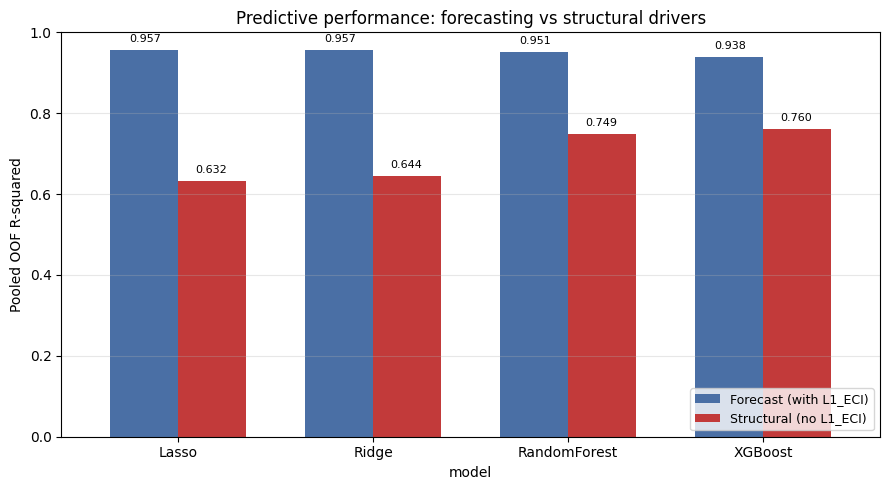


Done. Forecast and structural specs are now both available for comparison.


In [60]:
# ============================================================================
# STRUCTURAL SPEC: same ML pipeline with L1_ECI removed.
# The forecast spec above achieves R^2 around 0.96, dominated by the
# autoregressive lag L1_ECI. That is appropriate for forecasting accuracy
# benchmarks but masks the contribution of structural drivers. Removing
# L1_ECI gives a fairer picture of which features actually carry information
# about economic complexity beyond yesterday's value.
# ============================================================================
print('=' * 70)
print('STRUCTURAL SPEC (L1_ECI removed)')
print('=' * 70)

STRUCTURAL_EXCLUDE = {'L1_ECI', 'log_GDPpc'}  # autoregressive lag + GDP per capita (another economic-performance measure, entangled with ECI)
FEATURES_STRUCTURAL = [c for c in FEATURES if c not in STRUCTURAL_EXCLUDE]
print(f'Structural feature set: {len(FEATURES_STRUCTURAL)} features (was {len(FEATURES)})')

# Train across imputations using the new feature_list parameter
struct_results = []
struct_oof = {}
t0 = time.time()

for imp_id, panel in iter_imputations():
    t_i = time.time()
    eng = engineer_features(panel)
    res = train_models(eng, feature_list=FEATURES_STRUCTURAL)
    if res is None:
        print(f'  imp {imp_id}: empty panel after dropna')
        continue
    for name in res['models']:
        scores = res['fold_scores'][name]
        oof = res['oof'][name]
        mask = ~np.isnan(oof)
        struct_results.append({
            'imputation': imp_id,
            'model': name,
            'cv_r2_mean': float(np.mean(scores)),
            'cv_r2_std':  float(np.std(scores)),
            'oof_r2':     r2_score(res['y'][mask], oof[mask]) if mask.any() else np.nan,
            'oof_mae':    mean_absolute_error(res['y'][mask], oof[mask]) if mask.any() else np.nan,
            'oof_rmse':   np.sqrt(mean_squared_error(res['y'][mask], oof[mask])) if mask.any() else np.nan,
            'n_train':    int(mask.sum()),
        })
    struct_oof[imp_id] = res
    print(f'  imp {imp_id}: trained in {time.time() - t_i:.1f}s')

print(f'\nStructural training: {time.time() - t0:.1f}s total')
struct_df = pd.DataFrame(struct_results)
print('\nPer-imputation results (structural spec):')
print(struct_df.to_string(index=False))

# Pool across imputations
struct_pooled = []
for name in struct_df['model'].unique():
    preds_list = []
    for imp_id, res in struct_oof.items():
        pred_df = res['sub'].copy()
        pred_df['pred'] = res['oof'][name]
        pred_df = pred_df.dropna(subset=['pred'])
        preds_list.append(pred_df)
    stacked = pd.concat(preds_list, ignore_index=True)
    if len(stacked) == 0:
        continue
    pooled_pred = stacked.groupby(['Country Code', 'Year'])['pred'].mean().reset_index()
    obs = pd.read_csv(INTER / 'Master_v2_observed.csv')
    truth = obs[['Country Code', 'Year', 'Economic Complexity Index']].dropna()
    merged = truth.merge(pooled_pred, on=['Country Code', 'Year'], how='inner')
    if len(merged) == 0:
        continue
    struct_pooled.append({
        'model':       name,
        'pooled_r2':   r2_score(merged['Economic Complexity Index'], merged['pred']),
        'pooled_mae':  mean_absolute_error(merged['Economic Complexity Index'], merged['pred']),
        'pooled_rmse': np.sqrt(mean_squared_error(merged['Economic Complexity Index'], merged['pred'])),
        'n_pooled':    len(merged),
    })
struct_pooled_df = pd.DataFrame(struct_pooled)
print('\nPooled across M=5 (structural spec, evaluated on observed-only ECI):')
print(struct_pooled_df.to_string(index=False))

struct_df.to_csv(INTER / _suffix('e4_results_structural.csv'), index=False)
struct_pooled_df.to_csv(INTER / _suffix('e4_results_structural_pooled.csv'), index=False)
print('\nSaved: e4_results_structural.csv, e4_results_structural_pooled.csv')

# SHAP for structural spec (on RandomForest)
if HAS_SHAP:
    print('\nComputing SHAP for structural spec...')
    struct_shap_rows = []
    t0 = time.time()
    for imp_id, res in struct_oof.items():
        t_i = time.time()
        rf_model = res['models']['RandomForest']
        explainer = shap.TreeExplainer(rf_model)
        shap_vals = explainer.shap_values(res['X'])
        mean_abs = np.abs(shap_vals).mean(axis=0)
        for f, v in zip(FEATURES_STRUCTURAL, mean_abs):
            struct_shap_rows.append({'imputation': imp_id, 'feature': f, 'shap_abs_mean': v})
        print(f'  imp {imp_id} done in {time.time() - t_i:.1f}s')

    struct_shap_df = pd.DataFrame(struct_shap_rows)
    struct_shap_agg = (struct_shap_df.groupby('feature')['shap_abs_mean']
                       .agg(['mean', 'std', 'count'])
                       .reset_index()
                       .rename(columns={'mean': 'shap_mean', 'std': 'shap_std'})
                       .sort_values('shap_mean', ascending=False))
    struct_shap_agg['shap_sd_rel'] = struct_shap_agg['shap_std'] / struct_shap_agg['shap_mean'].replace(0, np.nan)
    print(f'\nSHAP total: {time.time() - t0:.1f}s')
    print('\nStructural spec, top 15 features by pooled SHAP:')
    print(struct_shap_agg.head(15).to_string(index=False))
    struct_shap_agg.to_csv(INTER / _suffix('e4_shap_structural.csv'), index=False)
    print('\nSaved: e4_shap_structural.csv')

# Forecast vs structural comparison plot
fig, ax = plt.subplots(figsize=(9, 5))
forecast_r2 = pooled_df.set_index('model')['pooled_r2']
struct_r2 = struct_pooled_df.set_index('model')['pooled_r2']
model_order = ['Lasso', 'Ridge', 'RandomForest', 'XGBoost']
model_order = [m for m in model_order if m in forecast_r2.index and m in struct_r2.index]
compare = pd.DataFrame({
    'Forecast (with L1_ECI)':  forecast_r2.reindex(model_order),
    'Structural (no L1_ECI)':  struct_r2.reindex(model_order),
})
compare.plot(kind='bar', ax=ax, color=['#4a6fa5', '#c23a3a'], width=0.7)
ax.set_ylabel('Pooled OOF R-squared')
ax.set_title('Predictive performance: forecasting vs structural drivers')
ax.set_xticklabels(compare.index, rotation=0)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, 1.0)
for i, (m, row) in enumerate(compare.iterrows()):
    ax.text(i - 0.17, row.iloc[0] + 0.02, f'{row.iloc[0]:.3f}', ha='center', fontsize=8)
    ax.text(i + 0.17, row.iloc[1] + 0.02, f'{row.iloc[1]:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(GRAPHICS / _suffix('forecast_vs_structural_r2.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nDone. Forecast and structural specs are now both available for comparison.')
